<a href="https://colab.research.google.com/github/layal-z/AAI614_Zeineddine/blob/data_vision/Graded_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
print(tf.__version__)  # For TensorFlow version

2.20.0


In [2]:
!pip list

Package                               Version
------------------------------------- ------------------
absl-py                               1.4.0
accelerate                            1.14.0
access                                1.1.10.post3
affine                                2.4.0
aiofiles                              25.1.0
aiohappyeyeballs                      2.7.1
aiohttp                               3.14.1
aiosignal                             1.4.0
aiosqlite                             0.22.1
alabaster                             1.0.0
albucore                              0.0.24
albumentations                        2.0.8
ale-py                                0.12.0
altair                                5.5.0
annotated-doc                         0.0.4
annotated-types                       0.7.0
antlr4-python3-runtime                4.9.3
anyio                                 4.14.2
anywidget                             0.9.21
apsw                                  3.53.3.1

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# for data load
import os

# # Libraries for reading and processing images
from IPython.display import Image, display
from keras.utils import load_img
from PIL import ImageOps
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow import io as tf_io

# for visualizations
import matplotlib.pyplot as plt

import numpy as np # for using np arrays
import random

# for bulding and running deep learning model
import keras
import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import concatenate
from tensorflow.keras.losses import binary_crossentropy
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16

# U-Net Decoder Block

This code defines the decoder block for the U-Net architecture, which is responsible for upsampling the feature maps and merging them with skip connections from the corresponding encoder block. The block starts with a transpose convolution layer to increase the size of the feature maps. Then, it merges the upsampled feature maps with the skip connection from the encoder block to preserve spatial information. Finally, two convolutional layers with ReLU activation and HeNormal initialization are applied to refine the features. This decoder block plays a vital role in reconstructing high-resolution segmentation masks from the encoded features, enabling the U-Net to produce accurate segmentation results.

In [5]:
def DecoderMiniBlock(prev_layer_input, skip_layer_input, n_filters=32):
    """
    Decoder Block first uses transpose convolution to upscale the image to a bigger size and then,
    merges the result with skip layer results from encoder block
    Adding 2 convolutions with 'same' padding helps further increase the depth of the network for better predictions
    The function returns the decoded layer output
    """
    # Start with a transpose convolution layer to first increase the size of the image
    up = Conv2DTranspose(
                 n_filters,
                 (3,3),    # Kernel size
                 strides=(2,2),
                 padding='same')(prev_layer_input)

    # Merge the skip connection from previous block to prevent information loss
    merge = concatenate([up, skip_layer_input], axis=3)

    # Add 2 Conv Layers with relu activation and HeNormal initialization for further processing
    # The parameters for the function are similar to encoder
    conv = Conv2D(n_filters,
                 3,     # Kernel size
                 activation='relu',
                 padding='same',
                 kernel_initializer='HeNormal')(merge)
    conv = Conv2D(n_filters,
                 3,   # Kernel size
                 activation='relu',
                 padding='same',
                 kernel_initializer='HeNormal')(conv)
    return conv

# U-Net Encoder Block

This code defines the encoder block for the U-Net architecture, commonly used in image segmentation tasks. The block consists of two convolutional layers with ReLU activation and batch normalization for feature extraction. Optionally, dropout regularization is applied to prevent overfitting. If specified, max pooling is performed to downsample the spatial dimensions of the input. Additionally, a skip connection is established to preserve spatial information for the decoder part of the network. This encoder block plays a crucial role in extracting hierarchical features from the input image, facilitating the U-Net's ability to capture detailed information for accurate segmentation.

In [6]:
def EncoderMiniBlock(inputs, n_filters=32, dropout_prob=0.3, max_pooling=True):
    """
    This block uses multiple convolution layers, max pool, relu activation to create an architecture for learning.
    Dropout can be added for regularization to prevent overfitting.
    The block returns the activation values for next layer along with a skip connection which will be used in the decoder
    """
    # Add 2 Conv Layers with relu activation and HeNormal initialization using TensorFlow
    # Proper initialization prevents from the problem of exploding and vanishing gradients
    # 'Same' padding will pad the input to conv layer such that the output has the same height and width (hence, is not reduced in size)
    conv = Conv2D(n_filters,
                  3,   # Kernel size
                  activation='relu',
                  padding='same',
                  kernel_initializer='HeNormal')(inputs)
    conv = Conv2D(n_filters,
                  3,   # Kernel size
                  activation='relu',
                  padding='same',
                  kernel_initializer='HeNormal')(conv)

    # Batch Normalization will normalize the output of the last layer based on the batch's mean and standard deviation
    conv = BatchNormalization()(conv, training=False)

    # In case of overfitting, dropout will regularize the loss and gradient computation to shrink the influence of weights on output
    if dropout_prob > 0:
        conv = tf.keras.layers.Dropout(dropout_prob)(conv)

    # Pooling reduces the size of the image while keeping the number of channels same
    # Pooling has been kept as optional as the last encoder layer does not use pooling (hence, makes the encoder block flexible to use)
    # Below, Max pooling considers the maximum of the input slice for output computation and uses stride of 2 to traverse across input image
    if max_pooling:
        next_layer = tf.keras.layers.MaxPooling2D(pool_size = (2,2))(conv)
    else:
        next_layer = conv

    # skip connection (without max pooling) will be input to the decoder layer to prevent information loss during transpose convolutions
    skip_connection = conv

    return next_layer, skip_connection

# Constructing the U-Net Model (without transfer learning)

This function constructs the complete U-Net model by combining both the encoder and decoder blocks. The encoder consists of multiple convolutional mini-blocks with increasing filter sizes and varying configurations for max-pooling and dropout. Each encoder block produces a skip connection that is passed to the corresponding decoder block. The decoder reverses the process, gradually decreasing the number of filters while upsampling the feature maps and incorporating skip connections to preserve spatial information. Finally, the model is completed with convolutional layers to produce the desired output size, with the number of channels matching the specified number of output classes. This compiled U-Net model is ready for training and inference on segmentation tasks.

In [7]:
def UNetCompiled(input_size=(128, 128, 3), n_filters=32, n_classes=3):
   """
   Combine both encoder and decoder blocks according to the U-Net research paper
   Return the model as output
   """
   # Input size represent the size of 1 image (the size used for pre-processing)
   inputs = Input(input_size)

   # Encoder includes multiple convolutional mini blocks with different maxpooling, dropout and filter parameters
   # Observe that the filters are increasing as we go deeper into the network which will increasse the # channels of the image
   cblock1 = EncoderMiniBlock(inputs, n_filters,dropout_prob=0, max_pooling=True)
   cblock2 = EncoderMiniBlock(cblock1[0],n_filters*2,dropout_prob=0, max_pooling=True)
   cblock3 = EncoderMiniBlock(cblock2[0], n_filters*4,dropout_prob=0, max_pooling=True)
   cblock4 = EncoderMiniBlock(cblock3[0], n_filters*8,dropout_prob=0.3, max_pooling=True)
   cblock5 = EncoderMiniBlock(cblock4[0], n_filters*16, dropout_prob=0.3, max_pooling=False)

   # Decoder includes multiple mini blocks with decreasing number of filters
   # Observe the skip connections from the encoder are given as input to the decoder
   # Recall the 2nd output of encoder block was skip connection, hence cblockn[1] is used
   ublock6 = DecoderMiniBlock(cblock5[0], cblock4[1],  n_filters * 8)
   ublock7 = DecoderMiniBlock(ublock6, cblock3[1],  n_filters * 4)
   ublock8 = DecoderMiniBlock(ublock7, cblock2[1],  n_filters * 2)
   ublock9 = DecoderMiniBlock(ublock8, cblock1[1],  n_filters)

   # Complete the model with 1 3x3 convolution layer (Same as the prev Conv Layers)
   # Followed by a 1x1 Conv layer to get the image to the desired size.
   # Observe the number of channels will be equal to number of output classes
   conv9 = Conv2D(n_filters,
                 3,
                 activation='relu',
                 padding='same',
                 kernel_initializer='he_normal')(ublock9)

   conv10 = Conv2D(n_classes, 1, padding='same')(conv9)

   # Define the model
   model = tf.keras.Model(inputs=inputs, outputs=conv10)

   return model

# Building the U-Net Model without Transfer Learning

This code initializes the U-Net model by calling the UNetCompiled function, which defines the architecture of the neural network. The function takes parameters such as input size, number of filters, and number of output classes. In this case, the input image size is set to 128x128 with 3 channels (RGB), and the model is designed to have 32 filters in its layers and output into 3 classes. Additionally, the model is compiled, which involves configuring the training process with specific parameters such as loss function, optimizer, and metrics.

The three classes typically correspond to:

- Background: This class represents the background of the image, including areas that do not contain any pets.
- Foreground/Pet: This class represents the main subject of interest in the image, which is typically a pet (such as a cat or a dog).
- Boundary/Trimap: This class represents the boundary around the pet object, delineating its edges and helping to refine the segmentation.



In [8]:
# Call the helper function for defining the layers for the model, given the input image size
unet = UNetCompiled(input_size=(128,128,3), n_filters=32, n_classes=3)

# **Graded Cell: U-Net model with a VGG16 encoder**

Complete the following function named build_unet_with_vgg16_encoder that takes input_shape as an argument.

- Input Layer:Define the input layer using the Input class with the provided input_shape.

- Load VGG16 Model: Load the VGG16 model with pre-trained weights (imagenet). Make sure to exclude the top layers (include_top=False) and set the input_tensor to the previously defined input layer.

- Extract Encoder Layers: Extract the relevant layers from the VGG16 model that will be used as the encoder part of the U-Net. These layers correspond to different blocks of convolutional layers in the VGG16 model.

- Bridge Layer: Identify the output of the deepest convolutional layer in VGG16 (often from the fifth block) to serve as the bridge layer.

- Build Decoder Layers: Use the DecoderMiniBlock function to build the decoder part of the U-Net, starting from the bridge layer and proceeding through the extracted encoder layers.

- Final Convolutional Layers: Add a few more convolutional layers after the last decoder block to refine the final output. The last convolutional layer should reduce the number of channels to the number of desired output classes.

- Compile the Model: Define the model using the Model class, specifying the input and output tensors. Return the compiled model.


The following article might be helpful: Tomar, Nikhil. “VGG16 UNET Implementation in TensorFlow.” Idiot Developer, 3 Dec. 2021, [Article Link](idiotdeveloper.com/vgg16-unet-implementation-in-tensorflow/).

In [9]:
# Graded Cell
def build_unet_with_vgg16_encoder(input_shape):
   #Inputl ayer
    inputs = Input(input_shape)

    #loading VGG16 with ImageNet weights and exclude VGG16’s classification head
    vgg16 = VGG16(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )

    #Encoder: outputs from VGG16 blocks as skip connections
    cblock1 = vgg16.get_layer('block1_conv2').output
    cblock2 = vgg16.get_layer('block2_conv2').output
    cblock3 = vgg16.get_layer('block3_conv3').output
    cblock4 = vgg16.get_layer('block4_conv3').output

    #Bridge: block5_conv3
    cblock5 = vgg16.get_layer('block5_conv3').output

    #Decoder from the created Decoder multiple mini blocks
    ublock6 = DecoderMiniBlock(cblock5, cblock4, 32 * 8)
    ublock7 = DecoderMiniBlock(ublock6, cblock3, 32 * 4)
    ublock8 = DecoderMiniBlock(ublock7, cblock2, 32 * 2)
    ublock9 = DecoderMiniBlock(ublock8, cblock1, 32)

    #Final convolutional layers, following the original U-Net
    conv9 = Conv2D(32, 3, activation='relu',padding='same',kernel_initializer='he_normal')(ublock9)

    # 3 output channels for the 3 segmentation classes
    conv10 = Conv2D(3,1,padding='same')(conv9)

    # Define/return the model
    model = Model(inputs=inputs,outputs=conv10)

    return model

# Building the U-Net Model with Transfer Learning

In [10]:
# Build the U-Net model with VGG16 encoder
model = build_unet_with_vgg16_encoder((128,128,3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Let's download and extract the Oxford-IIIT Pet Dataset. This dataset contains images of cats and dogs, along with annotations for pet breed and pixel-level segmentation masks. By downloading and extracting these files, we'll have access to the dataset for training and evaluating segmentation models.

In [14]:
#adding -L to curl which tells it to follow the website’s redirect and download the dataset,the original cell downloaded a 187 byte webpage instead of the archive which led to thee tar error.
#!!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
#!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
#!
#!curl -O https://thor.robots.ox.ac.uk/datasets/pets/images.tar.gz
#!curl -O https://thor.robots.ox.ac.uk/datasets/pets/annotations.tar.gz
#!
#!tar -xf images.tar.gz
#!tar -xf annotations.tar.gz
!rm -f images.tar.gz annotations.tar.gz

!curl -L -o images.tar.gz https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!curl -L -o annotations.tar.gz https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

!tar -xzf images.tar.gz
!tar -xzf annotations.tar.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   340  100   340    0     0    430      0 --:--:-- --:--:-- --:--:--   430
100  755M  100  755M    0     0  12.5M      0  0:01:00  0:01:00 --:--:-- 12.8M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   345  100   345    0     0    232      0  0:00:01  0:00:01 --:--:--   232
100 18.2M  100 18.2M    0     0  4097k      0  0:00:04  0:00:04 --:--:-- 8029k


# Preprocessing and Dataset Construction

The following code loads images and their corresponding masks (annotations) from directories, preprocesses them, and constructs a TensorFlow dataset for training a segmentation model. It first collects file paths for images and masks, then defines functions to load and preprocess them using TensorFlow's IO and image processing modules. After defining a function to create a dataset from these paths, it constructs the dataset using specified batch size and image size. Finally, it iterates through the dataset, collecting batches of input images and target masks into arrays, which are then concatenated to form the complete input and target datasets for training the segmentation model.

In [15]:
input_dir = "images/"
target_dir = "annotations/trimaps/"
img_size = (128, 128)
batch_size = 32

input_img_paths = sorted([
    os.path.join(input_dir, fname)
    for fname in os.listdir(input_dir)
    if fname.endswith(".jpg")
])

target_img_paths = sorted([
    os.path.join(target_dir, fname)
    for fname in os.listdir(target_dir)
    if fname.endswith(".png") and not fname.startswith(".")
])

print("Number of samples:", len(input_img_paths))

for input_path, target_path in zip(input_img_paths[:10], target_img_paths[:10]):
    print(input_path, "|", target_path)

def load_img_masks(input_img_path, target_img_path):
    input_img = tf_io.read_file(input_img_path)
    input_img = tf_io.decode_jpeg(input_img, channels=3)
    input_img = tf_image.resize(input_img, img_size)
    input_img = tf_image.convert_image_dtype(input_img, tf.float32)

    target_img = tf_io.read_file(target_img_path)
    target_img = tf_io.decode_png(target_img, channels=1)
    target_img = tf_image.resize(target_img, img_size, method="nearest")
    target_img = tf.squeeze(target_img, axis=-1)  # Remove the channel dimension
    target_img = tf_image.convert_image_dtype(target_img, tf.uint8)

    # Ground truth labels are 1, 2, 3. Subtract one to make them 0, 1, 2:
    target_img -= 1
    return input_img, target_img

def get_dataset(
    batch_size,
    img_size,
    input_img_paths,
    target_img_paths,
    max_dataset_len=None,
):
    """Returns a TF Dataset."""
    # For faster debugging, limit the size of data
    if max_dataset_len:
        input_img_paths = input_img_paths[:max_dataset_len]
        target_img_paths = target_img_paths[:max_dataset_len]
    dataset = tf_data.Dataset.from_tensor_slices((input_img_paths, target_img_paths))
    dataset = dataset.map(load_img_masks, num_parallel_calls=tf_data.AUTOTUNE)
    return dataset.batch(batch_size)

# Get the dataset
dataset = get_dataset(
    batch_size=batch_size,
    img_size=img_size,
    input_img_paths=input_img_paths,
    target_img_paths=target_img_paths
)

# Collect batches from the dataset into arrays or tensors
X_batches = []
y_batches = []
for X_batch, y_batch in dataset:
    X_batches.append(X_batch.numpy())  # Convert TensorFlow tensor to numpy array
    y_batches.append(y_batch.numpy())  # Convert TensorFlow tensor to numpy array

# Concatenate batches into a single array or tensor
X = np.concatenate(X_batches, axis=0)
y = np.concatenate(y_batches, axis=0)


Number of samples: 7390
images/Abyssinian_1.jpg | annotations/trimaps/Abyssinian_1.png
images/Abyssinian_10.jpg | annotations/trimaps/Abyssinian_10.png
images/Abyssinian_100.jpg | annotations/trimaps/Abyssinian_100.png
images/Abyssinian_101.jpg | annotations/trimaps/Abyssinian_101.png
images/Abyssinian_102.jpg | annotations/trimaps/Abyssinian_102.png
images/Abyssinian_103.jpg | annotations/trimaps/Abyssinian_103.png
images/Abyssinian_104.jpg | annotations/trimaps/Abyssinian_104.png
images/Abyssinian_105.jpg | annotations/trimaps/Abyssinian_105.png
images/Abyssinian_106.jpg | annotations/trimaps/Abyssinian_106.png
images/Abyssinian_107.jpg | annotations/trimaps/Abyssinian_107.png


In [17]:
# Use scikit-learn's function to split the dataset
# 20% data as test/valid set
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=123)
print("Training:", len(X_train))
print("Validation:", len(X_valid))

Training: 5912
Validation: 1478


# Training the UNet Model for Image Segmentation on the Oxford Dataset

This code compiles and trains a UNet model for image segmentation using the Oxford dataset with and without transfer learning. It configures the model with the Adam optimizer and sparse categorical crossentropy loss function, suitable for integer-based target labels. Additionally, it includes a ModelCheckpoint callback to save the best model during training and runs training for 20 epochs, validating the model's performance after each epoch.

In [18]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

callbacks = [
    keras.callbacks.ModelCheckpoint("oxford_segmentation_transfer_learning.keras", save_best_only=True)
]

# Run the model in a mini-batch fashion and compute the progress for each epoch
results_vgg16 = model.fit(X_train, y_train, batch_size=32, epochs=20,
                    validation_data=(X_valid, y_valid),callbacks=callbacks,)

Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 196s 781ms/step - accuracy: 0.6666 - loss: 35.7910 - val_accuracy: 0.7761 - val_loss: 7.2328
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 70s 380ms/step - accuracy: 0.8097 - loss: 3.8048 - val_accuracy: 0.8101 - val_loss: 1.6949
Epoch 3/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 73s 396ms/step - accuracy: 0.8010 - loss: 0.8716 - val_accuracy: 0.8068 - val_loss: 0.5927
Epoch 4/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 75s 407ms/step - accuracy: 0.8205 - loss: 0.4716 - val_accuracy: 0.8267 - val_loss: 0.5027
Epoch 5/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 77s 415ms/step - accuracy: 0.8393 - loss: 0.4073 - val_accuracy: 0.8354 - val_loss: 0.4605
Epoch 6/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 76s 413ms/step - accuracy: 0.8519 - loss: 0.3669 - val_accuracy: 0.8508 - val_loss: 0.4816
Epoch 7/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 76s 413ms/step - accuracy: 0.8636 - loss: 0.3273 - val_accuracy: 0.8562 - val_loss: 0.4605
Epoch 8/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 76s 411ms/step - accuracy: 0.8705 - loss:

In [19]:
unet.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

callbacks = [
    keras.callbacks.ModelCheckpoint("oxford_segmentation.keras", save_best_only=True)
]

# Run the model in a mini-batch fashion and compute the progress for each epoch
results = unet.fit(X_train, y_train, batch_size=32, epochs=20,
                    validation_data=(X_valid, y_valid),callbacks=callbacks,)

Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 86s 328ms/step - accuracy: 0.7146 - loss: 0.6833 - val_accuracy: 0.6351 - val_loss: 0.8644
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 37s 201ms/step - accuracy: 0.8034 - loss: 0.4988 - val_accuracy: 0.7971 - val_loss: 0.5198
Epoch 3/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 39s 210ms/step - accuracy: 0.8323 - loss: 0.4293 - val_accuracy: 0.8301 - val_loss: 0.4437
Epoch 4/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 40s 217ms/step - accuracy: 0.8484 - loss: 0.3893 - val_accuracy: 0.8394 - val_loss: 0.4388
Epoch 5/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 41s 219ms/step - accuracy: 0.8608 - loss: 0.3569 - val_accuracy: 0.8446 - val_loss: 0.4099
Epoch 6/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 41s 219ms/step - accuracy: 0.8695 - loss: 0.3347 - val_accuracy: 0.8450 - val_loss: 0.4148
Epoch 7/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 41s 224ms/step - accuracy: 0.8787 - loss: 0.3101 - val_accuracy: 0.8452 - val_loss: 0.4431
Epoch 8/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 42s 227ms/step - accuracy: 0.8856 - loss: 0

# Displaying Predicted Masks Alongside Input Images and Actual Masks for the model without transfer learning

47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step


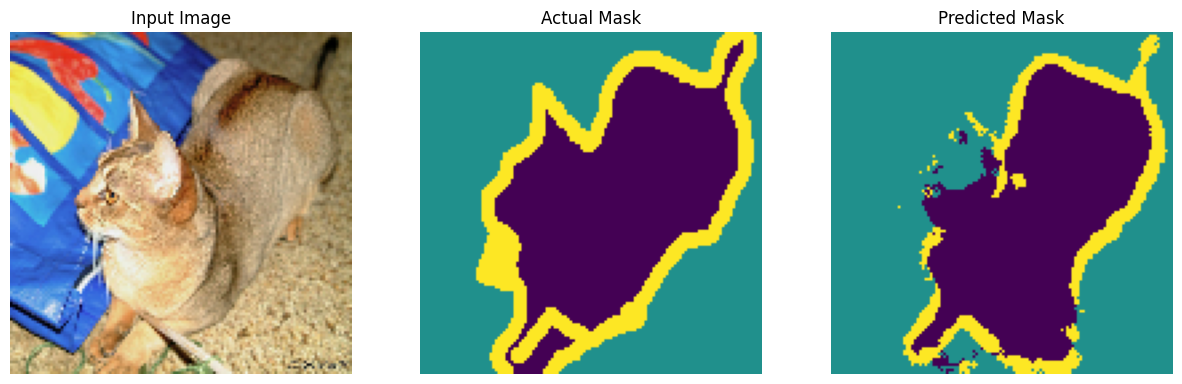

In [20]:
# Generate predictions for all images in the validation set
val_preds = unet.predict(X_valid)

def display_masks_side_by_side(input_image, actual_mask, predicted_mask):
    """Display input image, actual mask, and predicted mask side by side."""
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    # Display input image
    # Normalize input image to range [0, 1]
    input_image_norm = input_image.astype(np.float32) / 255.0

    axs[0].imshow(input_image_norm)
    axs[0].set_title('Input Image')
    axs[0].axis('off')

    # Display actual mask
    axs[1].imshow(actual_mask)  # Remove indexing since actual_mask is a 2D array
    axs[1].set_title('Actual Mask')
    axs[1].axis('off')

    # Convert predicted mask to numpy array
    predicted_mask_np = np.argmax(predicted_mask, axis=-1)

    # Display predicted mask
    axs[2].imshow(predicted_mask_np)
    axs[2].set_title('Predicted Mask')
    axs[2].axis('off')

# Display results for validation image #10
i = 10

# Load input image (assuming X_valid contains the input images)
input_image =X_valid[i]

# Load actual mask (assuming y_valid contains the actual masks)
actual_mask = y_valid[i]

# Display input image, actual mask, and predicted mask side by side
display_masks_side_by_side(input_image, actual_mask, val_preds[i])


# Displaying Predicted Masks Alongside Input Images and Actual Masks for the model with transfer learning

47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step


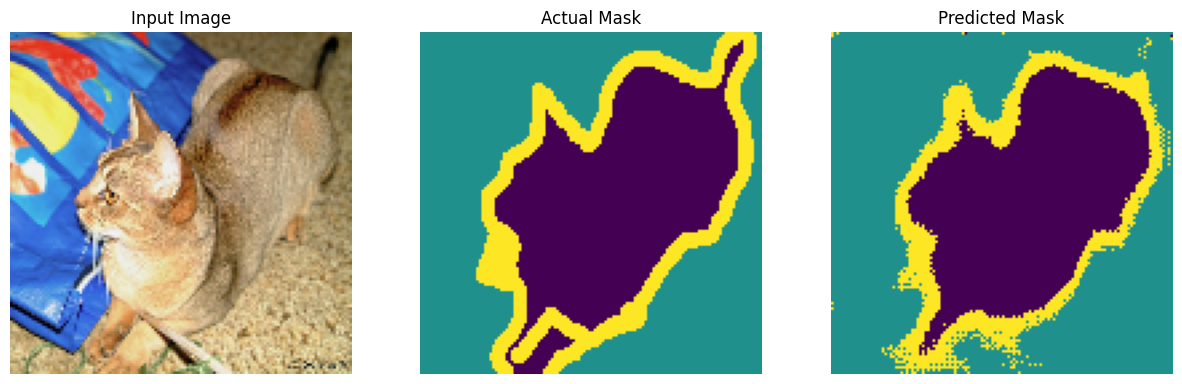

In [21]:
# Generate predictions for all images in the validation set
val_preds = model.predict(X_valid)

# Display results for validation image #10
i = 10

# Load input image (assuming X_valid contains the input images)
input_image =X_valid[i]

# Load actual mask (assuming y_valid contains the actual masks)
actual_mask = y_valid[i]

# Display input image, actual mask, and predicted mask side by side
display_masks_side_by_side(input_image, actual_mask, val_preds[i])


# Defining Evaluation Metrics

Define the following evaluation metrics: precision, recall, accuracy, dice coefficient, and Intersection-over-Union (IoU).

You can copy these definitions from this article: Huynh, Nghi. “Understanding Evaluation Metrics in Medical Image Segmentation.” Medium, 19 Mar. 2024. [Article Link](medium.com/@nghihuynh_37300/understanding-evaluation-metrics-in-medical-image-segmentation-d289a373a3f).

In [28]:
def precision_score_(groundtruth_mask, pred_mask):
  intersect = np.sum(pred_mask * groundtruth_mask)
  total_pixel_pred = np.sum(pred_mask)
  precision = np.mean(intersect / total_pixel_pred)
  return round(precision, 3)

def recall_score_(groundtruth_mask, pred_mask):
  intersect = np.sum(pred_mask * groundtruth_mask)
  total_pixel_truth = np.sum(groundtruth_mask)
  recall = np.mean(intersect / total_pixel_truth)
  return round(recall, 3)

def accuracy(groundtruth_mask, pred_mask):
  intersect = np.sum(pred_mask * groundtruth_mask)
  union = (
      np.sum(pred_mask)
      + np.sum(groundtruth_mask)
      - intersect
    )
  xor = np.sum(groundtruth_mask == pred_mask)
  acc = np.mean(
      xor / (union + xor - intersect)
    )
  return round(acc, 3)


def dice_coef(groundtruth_mask, pred_mask):
  intersect = np.sum(pred_mask * groundtruth_mask)
  total_sum = (
      np.sum(pred_mask)
      + np.sum(groundtruth_mask)
    )
  dice = np.mean(
      2 * intersect / total_sum
    )
  return round(dice, 3)



def iou(groundtruth_mask, pred_mask):
  intersect = np.sum(pred_mask * groundtruth_mask)
  union = (
      np.sum(pred_mask)
      + np.sum(groundtruth_mask)
      - intersect
    )
  iou = np.mean(intersect / union)
  return round(iou, 3)

# **Graded Cell: Model Evaluation**

- Predict on the Validation Set: Use the trained model to make predictions on the validation dataset (X_valid). The predictions (y_pred) will be in the form of probability distributions across the classes for each pixel.

- Convert Predictions to Class Labels: Use np.argmax to convert the predicted probability distributions to class labels. This will give the predicted class for each pixel.

- Flatten the Masks: Flatten both the ground truth masks (y_valid) and the predicted masks (y_pred). Flattening converts the 2D masks into 1D arrays, making it easier to calculate metrics.

- Convert Pixel Values to Binary: The evaluation metrics rely on generating a confusion matrix for a binary segmentation mask, comprising counts for true positives (TP), false positives (FP), true negatives (TN), and false negatives (FN) predictions. The values of all metrics discussed herein range from zero (indicating the poorest performance) to one (signifying the optimal performance). You need to convert the pixel values to binary (0 or 1). Use a threshold (e.g., 0.5) to decide the binary value for each pixel.

- Calculate Metrics: Use the provided metric functions (precision_score_, recall_score_, accuracy, dice_coef, iou) to compute the metrics on the binary masks.
        
- Finally, print the computed metrics.

# First Case: U-Net with Transfer Learning

In [31]:
# Step 1: Predict on the Validation Set
# Use your trained model to make predictions on the validation set
y_pred_vgg16 = model.predict(X_valid)


# Step 2: Convert Predictions to Class Labels
# Convert predicted probabilities to class labels
y_pred_vgg16 = np.argmax(y_pred_vgg16,axis=-1)

# Step 3: Flatten the Masks
# Flatten the ground truth masks and predicted masks
y_valid_flat = y_valid.flatten()
y_pred_vgg16_flat = y_pred_vgg16.flatten()


# Step 4: Convert Pixel Values to Binary
# Use a threshold: Values > 0.5 become 1 and class 0 remains 0
y_valid_binary = (y_valid_flat > 0.5).astype(int)
y_pred_vgg16_binary = (y_pred_vgg16_flat > 0.5).astype(int)


# Step 5: Calculate Metrics
# Calculate each metric using the provided functions
precision_vgg16 = precision_score_(y_valid_binary,y_pred_vgg16_binary)
recall_vgg16 = recall_score_(y_valid_binary,y_pred_vgg16_binary)
accuracy_vgg16 = accuracy(y_valid_binary,y_pred_vgg16_binary)
dice_vgg16 = dice_coef(y_valid_binary,y_pred_vgg16_binary)
iou_vgg16 = iou(y_valid_binary,y_pred_vgg16_binary)

# Print the results

print("U-Net with VGG16 Encoder")
print("Precision:", precision_vgg16)
print("Recall:", recall_vgg16)
print("Accuracy:", accuracy_vgg16)
print("Dice Coef.:", dice_vgg16)
print("IoU:", iou_vgg16)

47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step
U-Net with VGG16 Encoder
Precision: 0.966
Recall: 0.961
Accuracy: 0.948
Dice Coef.: 0.963
IoU: 0.929


# Second Case: U-Net without Transfer Learning

In [32]:
# Step 1: Predict on the Validation Set
# Use your trained model to make predictions on the validation set
y_pred_unet = unet.predict(X_valid)

# Step 2: Convert Predictions to Class Labels
# Convert predicted probabilities to class labels
y_pred_unet = np.argmax(y_pred_unet,axis=-1)

# Step 3: Flatten the Masks
# Flatten the ground truth masks and predicted masks
y_valid_flat = y_valid.flatten()
y_pred_unet_flat = y_pred_unet.flatten()

# Step 4: Convert Pixel Values to Binary
# Use a threshold
y_valid_binary = (y_valid_flat > 0.5).astype(int)
y_pred_unet_binary = (y_pred_unet_flat > 0.5).astype(int)

# Step 5: Calculate Metrics
# Calculate each metric using the provided functions
precision_unet = precision_score_(y_valid_binary,y_pred_unet_binary)
recall_unet = recall_score_(y_valid_binary,y_pred_unet_binary)
accuracy_unet = accuracy(y_valid_binary,y_pred_unet_binary)
dice_unet = dice_coef(y_valid_binary,y_pred_unet_binary)
iou_unet = iou(y_valid_binary,y_pred_unet_binary)

# Print the results
print("U-Net without Transfer Learning")
print("Precision:", precision_unet)
print("Recall:", recall_unet)
print("Accuracy:", accuracy_unet)
print("Dice Coef.:", dice_unet)
print("IoU:", iou_unet)


47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step
U-Net without Transfer Learning
Precision: 0.919
Recall: 0.956
Accuracy: 0.91
Dice Coef.: 0.937
IoU: 0.882


The evaluation results demonstrate that the U-Net with an ImageNet-pretrained VGG16 encoder performed better than the original U-Net without transfer learning across all five required segmentation metrics.


* Precision increased from 0.919 to 0.966: this means that a greater proportion of the pixels predicted as positive were true positives, consequently, the transfer-learning model generated fewer false-positive pixel classifications.

* Recall increased from 0.956 to 0.961, indicating that the VGG16 U-Net detected a slightly greater proportion of the actual positive pixels and missed fewer relevant pixels as false negatives.

* Accuracy increased from 0.910 to 0.948, showing improved overall classification of positive and negative pixels.

* The Dice coefficient increased from 0.937 to 0.963: this demonstrated greater similarity and overlap between the predicted and ground-truth masks.

* IoU also increased substantially from 0.882 to 0.929: this signals stronger agreement between the intersection and complete union of the predicted and ground-truth regions.

The visual results support the numerical evaluation: the VGG16 U-Net produced a more coherent segmentation of the cat's body and head, while the original U-Net showed greater fragmentation around the head and object boundaries. Overall, the higher precision, recall, accuracy, Dice coefficient, and IoU demonstrate that transfer learning improved segmentation performance. The pretrained VGG16 encoder provided previously learned visual features, while the U-Net skip connections preserved spatial information required by the decoder to produce a mask that agreed more closely with the ground truth.

